# Project: Neutrino Portal at the Muon Collider

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import pathlib
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json

## Check

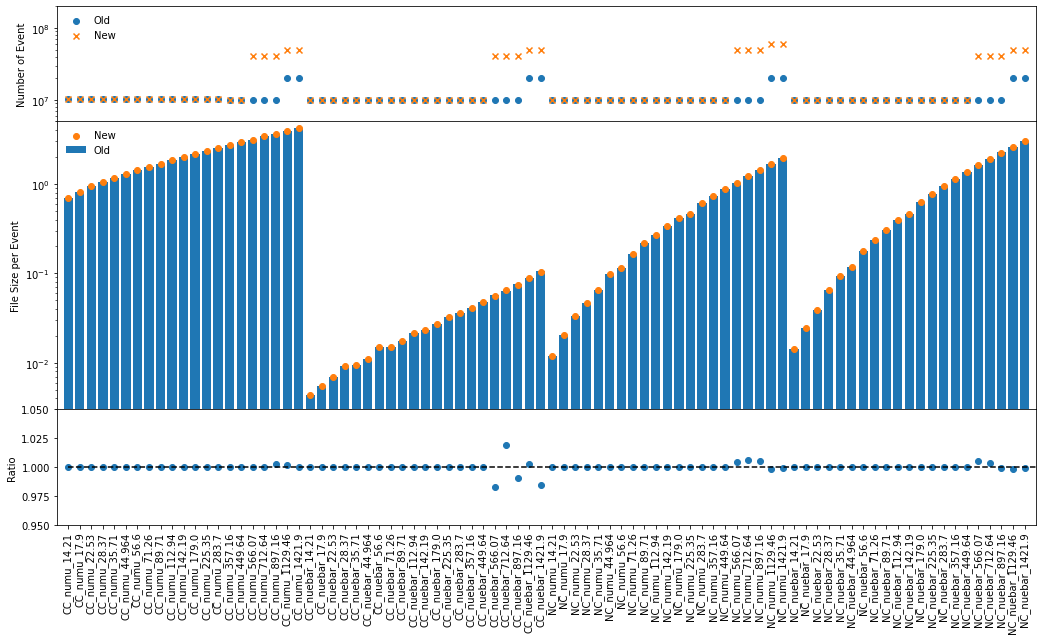

In [2]:
# old results 
results_old = {
 'CC_numu_14.21': [10201000, 7115275, 0.6975075972943829],
 'CC_numu_17.9': [10201000, 8305056, 0.8141413586903244],
 'CC_numu_22.53': [10201000, 9568136, 0.9379605920988139],
 'CC_numu_28.37': [10201000, 10611954, 1.0402856582687972],
 'CC_numu_35.71': [10201000, 11859703, 1.1626019998039407],
 'CC_numu_44.964': [10201000, 13220681, 1.296018135476914],
 'CC_numu_56.6': [10201000, 14477456, 1.4192192922262523],
 'CC_numu_71.26': [10201000, 15674703, 1.5365849426526812],
 'CC_numu_89.71': [10201000, 17179590, 1.6841084207430643],
 'CC_numu_112.94': [10201000, 18762947, 1.839324281933144],
 'CC_numu_142.19': [10201000, 20248365, 1.9849392216449369],
 'CC_numu_179.0': [10201000, 22051130, 2.1616635623958436],
 'CC_numu_225.35': [10201000, 23707225, 2.324009900990099],
 'CC_numu_283.7': [10201000, 25599401, 2.509499166748358],
 'CC_numu_357.16': [10101000, 27389434, 2.7115566775566777],
 'CC_numu_449.64': [10101000, 29597472, 2.9301526581526582],
 'CC_numu_566.07': [10101000, 31692380, 3.1375487575487577],
 'CC_numu_712.64': [10101000, 34312388, 3.396929808929809],
 'CC_numu_897.16': [10101000, 36702010, 3.6335026235026233],
 'CC_numu_1129.46': [20101000, 79209393, 3.940569772648127],
 'CC_numu_1421.9': [20103000, 85014560, 4.228948913097548],
 'CC_nuebar_14.21': [10101000, 43870, 0.004343134343134343],
 'CC_nuebar_17.9': [10101000, 55580, 0.005502425502425502],
 'CC_nuebar_22.53': [10101000, 69358, 0.0068664488664488665],
 'CC_nuebar_28.37': [10101000, 93128, 0.00921968121968122],
 'CC_nuebar_35.71': [10101000, 95251, 0.00942985842985843],
 'CC_nuebar_44.964': [10101000, 110238, 0.010913572913572913],
 'CC_nuebar_56.6': [10101000, 152581, 0.015105534105534106],
 'CC_nuebar_71.26': [10101000, 149728, 0.014823086823086824],
 'CC_nuebar_89.71': [10101000, 178138, 0.017635679635679635],
 'CC_nuebar_112.94': [10101000, 217717, 0.021554004554004556],
 'CC_nuebar_142.19': [10101000, 235222, 0.023287001287001285],
 'CC_nuebar_179.0': [10101000, 276402, 0.027363825363825364],
 'CC_nuebar_225.35': [10101000, 324456, 0.03212117612117612],
 'CC_nuebar_283.7': [10101000, 366611, 0.036294525294525294],
 'CC_nuebar_357.16': [10101000, 417566, 0.04133907533907534],
 'CC_nuebar_449.64': [10101000, 481832, 0.0477014157014157],
 'CC_nuebar_566.07': [10101000, 571951, 0.05662320562320562],
 'CC_nuebar_712.64': [10101000, 638124, 0.06317433917433918],
 'CC_nuebar_897.16': [10101000, 764348, 0.07567052767052768],
 'CC_nuebar_1129.46': [20101000, 1792265, 0.08916297696632008],
 'CC_nuebar_1421.9': [20101000, 2128978, 0.10591403412765533],
 'NC_numu_14.21': [10101000, 119044, 0.011785367785367786],
 'NC_numu_17.9': [10101000, 207376, 0.020530244530244532],
 'NC_numu_22.53': [10101000, 337375, 0.0334001584001584],
 'NC_numu_28.37': [10101000, 473469, 0.04687347787347787],
 'NC_numu_35.71': [10101000, 663786, 0.06571487971487971],
 'NC_numu_44.964': [10101000, 981454, 0.09716404316404316],
 'NC_numu_56.6': [10101000, 1153596, 0.1142061182061182],
 'NC_numu_71.26': [10101000, 1673258, 0.16565270765270765],
 'NC_numu_89.71': [10101000, 2187830, 0.2165953865953866],
 'NC_numu_112.94': [10101000, 2738540, 0.2711157311157311],
 'NC_numu_142.19': [10101000, 3386727, 0.3352863082863083],
 'NC_numu_179.0': [10101000, 4192044, 0.415012771012771],
 'NC_numu_225.35': [10101000, 4633700, 0.45873675873675873],
 'NC_numu_283.7': [10101000, 6210648, 0.6148547668547668],
 'NC_numu_357.16': [10101000, 7434540, 0.736020196020196],
 'NC_numu_449.64': [10101000, 8877431, 0.8788665478665478],
 'NC_numu_566.07': [10101000, 10432974, 1.0328654588654589],
 'NC_numu_712.64': [10101000, 12256097, 1.2133548163548165],
 'NC_numu_897.16': [10101000, 14361651, 1.4218048708048707],
 'NC_numu_1129.46': [20101000, 33644566, 1.6737757325506193],
 'NC_numu_1421.9': [20101000, 38931019, 1.9367702601860604],
 'NC_nuebar_14.21': [10101000, 144451, 0.014300663300663301],
 'NC_nuebar_17.9': [10101000, 247466, 0.0244991584991585],
 'NC_nuebar_22.53': [10101000, 393896, 0.038995742995742995],
 'NC_nuebar_28.37': [10101000, 658792, 0.06522047322047322],
 'NC_nuebar_35.71': [10101000, 935862, 0.09265043065043065],
 'NC_nuebar_44.964': [10101000, 1187185, 0.11753143253143253],
 'NC_nuebar_56.6': [10101000, 1780371, 0.17625690525690527],
 'NC_nuebar_71.26': [10101000, 2358952, 0.23353648153648154],
 'NC_nuebar_89.71': [10101000, 3102794, 0.3071769131769132],
 'NC_nuebar_112.94': [10101000, 4034563, 0.3994221364221364],
 'NC_nuebar_142.19': [10101000, 4600307, 0.4554308484308484],
 'NC_nuebar_179.0': [10101000, 6275990, 0.6213236313236313],
 'NC_nuebar_225.35': [10101000, 7857672, 0.7779103059103059],
 'NC_nuebar_283.7': [10101000, 9563428, 0.9467803187803188],
 'NC_nuebar_357.16': [10101000, 11558405, 1.1442832392832394],
 'NC_nuebar_449.64': [10101000, 13703741, 1.3566717156717156],
 'NC_nuebar_566.07': [10101000, 16473766, 1.6309044649044648],
 'NC_nuebar_712.64': [10101000, 19365857, 1.9172217602217603],
 'NC_nuebar_897.16': [10101000, 22725979, 2.249874170874171],
 'NC_nuebar_1129.46': [20101000, 52696327, 2.6215773842097407],
 'NC_nuebar_1421.9': [20101000, 60260683, 2.9978947813541614]
}

# Loop through  
results = {}
processes_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar"]
energies = [ 14.21, 17.90, 22.53, 28.37, 35.71, 44.964, 56.60, 71.26, 89.71, 
    112.94, 142.19, 179.00, 225.35, 283.70, 357.16, 449.64, 566.07, 712.64, 897.16,
    1129.46, 1421.90, ] 
for process in processes_bg: 
    
    dirname = 'output_events_' + process  
    generated_data_name = dirname+"/generated_events.json"
    with open(generated_data_name, "r") as f: generated_data_raw = json.load(f)
    generated_data = {int(float(key)): value for key, value in generated_data_raw.items()}
            
    for energy in energies:
        
        filename = f"output_events_{process}/events_{str(energy)}.csv.zip"
        filesize = os.path.getsize(filename)
        nevent = generated_data[int(energy)]
        results[process+"_"+str(energy)] = [nevent, filesize, filesize/nevent]
        
# Plot 
fig = plt.figure(figsize=(16,8)) 
ax1 = fig.add_axes([0.14, 0.79, 0.85, 0.20], xticklabels=[], )
ax2 = fig.add_axes([0.14, 0.29, 0.85, 0.50],xticklabels=[], )
ax3 = fig.add_axes([0.14, 0.09, 0.85, 0.20],  )
    
    
# events
x,y = results_old.keys(), [results_old[i][0] for i in results_old.keys()]
ax1.scatter(x,y, label='Old')
x,y = results.keys(), [results[i][0] for i in results.keys()]
ax1.scatter(x,y, label='New',zorder=10, marker='x')

ax1.set_ylim(0.5e7, 2e8)
ax1.set_yscale('log')
ax1.set_xlim(-1,len(results))
ax1.legend(frameon=False, ncol=1,loc='upper left')
ax1.set_ylabel("Number of Event")

# file size per event
x,y = results_old.keys(), [results_old[i][2] for i in results_old.keys()]
ax2.bar(x,y, label='Old')
x,y = results.keys(), [results[i][2] for i in results.keys()]
ax2.scatter(x,y, label='New',zorder=10)
ax2.set_ylim(3e-3,5e0)
ax2.set_yscale('log')
ax2.set_xlim(-1,len(results))
ax2.legend(frameon=False, ncol=1,loc='upper left')
ax2.set_ylabel("File Size per Event")

# ratio
x,y = results_old.keys(), [results[i][2]/results_old[i][2] for i in results_old.keys()]
ax3.scatter(x,y,zorder=10)
ax3.plot([0,len(results)],[1,1],ls='dashed',c='k',zorder=10)

ax3.set_ylim(0.95,1.05)
ax3.set_xlim(-1,len(results))
ax3.set_ylabel("Ratio")
ax3.set_xticks(range(len(results)))  # Ensure x-ticks are set
ax3.set_xticklabels(results.keys(), rotation=90)  # Rotate the labels

plt.show()

## Common Analysis Functions

In [3]:
def fix_dataframe(data):

    # Initialize the column 'ievent' with zeros
    data['ievent'] = 0
    # Variable to keep track of the increment for column 'ievent'
    counter = 0
    # Loop through the DataFrame rows
    for index, row in data.iterrows():
        if row['iparticle'] == 0: counter += 1
        data.at[index, 'ievent'] = counter
    #return
    return data

def calculate_observables(data):
    events = []
    grouped_data = data.groupby('ievent')

    for ievent, evt in grouped_data:
        # Reset or initialize variables for each event
        e_mu_minus, e_mu_plus, has_charm, e_em, e_visible, ptx, pty, ht = 0, 0, 0, 0, 0, 0, 0, 0
        pt_mu_minus, pt_mu_minus, phi_mu_minus, phi_mu_minus = 0, 0, 0, 0
        
        # Iterate over particles in the event
        for _, row in evt.iterrows():
            truth_energy, pid, parent_pid1 = row.iloc[2], row.iloc[3], row.iloc[8]
            px, py, pz, e  =  row.iloc[4], row.iloc[5], row.iloc[6], row.iloc[7]
               
            # Check for charm particles
            if abs(parent_pid1) in {411, 421, 431, 4122,15,521,511,531,443,5122,4232,4112,5232}: 
                has_charm = 1
            
            # Update energies for mu- and mu+
            if pid == 13: 
                if e>e_mu_minus:
                    e_mu_minus = e
                    pt_mu_minus = np.sqrt(px**2 + py**2) 
                    phi_mu_minus = np.arctan2(py, px)
            elif pid == -13: 
                if e>e_mu_plus:
                    e_mu_plus = e
                    pt_mu_plus = np.sqrt(px**2 + py**2) 
                    phi_mu_plus = np.arctan2(py, px)
            
            # Sum EM and visible energy
            if abs(pid) in {22, 11}: 
                e_em += e
            if abs(pid) not in {12, 14, 16, 39}: 
                e_visible += e
                ptx += px
                pty += py
                ht += np.sqrt(px**2 + py**2)
        
        # Calculate missing pT
        pt_mis = np.sqrt(ptx**2 + pty**2)
        phi_vis = np.arctan2(pty, ptx)
        phi_mis = np.arctan2(-pty, -ptx)
        
        # Append event observables
        events.append([ievent, truth_energy, e_mu_minus, e_mu_plus, e_em, has_charm, e_visible, pt_mis, ht, pt_mu_minus, pt_mu_plus, phi_mu_minus, phi_mu_plus, phi_mis, phi_vis])

    # Construct DataFrame from results
    columns = ['ievent', 'truth_energy', 'e_mu_minus', 'e_mu_plus', 'e_em', 'has_charm', 'e_visible', 'pt_mis', 'ht', 'pt_mu_minus', 'pt_mu_plus', 'phi_mu_minus', 'phi_mu_plus', 'phi_mis', 'phi_vis']
    observables = pd.DataFrame(events, columns=columns)
    
    return observables


## Calculate Observables

-  read events from one file

In [4]:
data = pd.read_csv("output_events_NC_numu/events_225.35.csv.zip")
data

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,NaN,0,225.35,14,1.662,0.495,159.278,159.287,14,14
1,NaN,1,225.35,2212,-0.863,-0.384,7.046,7.171,2214,90
2,NaN,2,225.35,211,-0.278,-0.050,2.981,2.998,213,90
3,NaN,3,225.35,2212,0.544,-1.155,8.058,8.212,2214,90
4,NaN,4,225.35,-211,-0.213,0.211,2.590,2.611,-4224,90
...,...,...,...,...,...,...,...,...,...,...
352072,NaN,14,225.35,130,1.371,0.776,36.007,36.045,-311,-311
352073,NaN,15,225.35,2112,0.079,-0.047,6.258,6.329,3122,90
352074,NaN,16,225.35,130,0.003,0.105,7.381,7.399,-311,-311
352075,NaN,17,225.35,22,-0.038,0.036,0.765,0.766,111,90


- fix missing ievent entries

In [5]:
data = fix_dataframe(data)
data

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,1,0,225.35,14,1.662,0.495,159.278,159.287,14,14
1,1,1,225.35,2212,-0.863,-0.384,7.046,7.171,2214,90
2,1,2,225.35,211,-0.278,-0.050,2.981,2.998,213,90
3,1,3,225.35,2212,0.544,-1.155,8.058,8.212,2214,90
4,1,4,225.35,-211,-0.213,0.211,2.590,2.611,-4224,90
...,...,...,...,...,...,...,...,...,...,...
352072,16530,14,225.35,130,1.371,0.776,36.007,36.045,-311,-311
352073,16530,15,225.35,2112,0.079,-0.047,6.258,6.329,3122,90
352074,16530,16,225.35,130,0.003,0.105,7.381,7.399,-311,-311
352075,16530,17,225.35,22,-0.038,0.036,0.765,0.766,111,90


- evaulates all necessary obseravbles for each event

In [6]:
observables = calculate_observables(data)
observables

,ievent,truth_energy,e_mu_minus,e_mu_plus,e_em,has_charm,e_visible,pt_mis,ht,pt_mu_minus,pt_mu_plus,phi_mu_minus,phi_mu_plus,phi_mis,phi_vis
0,1,225.35,0.0,0.811,14.599,1,61.963,1.546889,7.769641,0.0,0.060166,0.0,-1.839964,-0.156434,2.985159
1,2,225.35,0.0,25.627,8.761,1,73.505,2.476487,7.097649,0.0,1.441185,0.0,-2.725130,0.449020,-2.692573
2,3,225.35,0.0,78.293,11.670,1,183.745,1.073695,5.589154,0.0,0.575641,0.0,-1.796814,-0.406971,2.734622
3,4,225.35,0.0,0.859,1.168,1,21.394,0.759329,4.261352,0.0,0.142056,0.0,1.542635,1.291954,-1.849639
4,5,225.35,0.0,0.250,19.675,1,80.574,4.876033,5.560138,0.0,0.206652,0.0,0.877917,0.647193,-2.494400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16525,16526,225.35,0.0,85.130,32.569,1,177.063,1.454830,4.673598,0.0,0.169567,0.0,-1.434737,-2.255413,0.886179
16526,16527,225.35,0.0,27.200,14.595,1,127.981,2.253364,6.486515,0.0,0.529941,0.0,-0.245894,-0.904927,2.236666
16527,16528,225.35,0.0,3.151,24.113,1,134.602,3.468713,6.163143,0.0,0.424726,0.0,2.309562,-1.513395,1.628198
16528,16529,225.35,0.0,14.151,15.821,1,49.523,3.888627,6.926140,0.0,1.691897,0.0,-2.380437,0.912482,-2.229110


- let us systematically calculate obvservables for all files

In [7]:
#define energies
energies = [
    #14.21, 17.90, 22.53, 28.37, 35.71, 44.964, 56.60, 71.26, 89.71, 
    #112.94, 142.19, 179.00, 225.35, 283.70, 357.16, 449.64, 
    566.07, 712.64, 897.16, 1129.46, 1421.90,
] 

#define processes
processes_bg = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar"]
processes_sig = ["0.001GeV","0.01GeV","0.05GeV","0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","16GeV","17.5GeV","18GeV","19.95GeV","21GeV","23GeV","25GeV","30GeV","40GeV"]
processes = processes_bg # + processes_sig

# Loop through all energies
for process in processes: 
    for energy in energies:
        filename = f"output_events_{process}/events_{str(energy)}.csv.zip"
        
        # Check if the file exists
        if not os.path.isfile(filename):
            print(f"File not found: {filename}")
            continue

        print(process, energy)
        data = pd.read_csv(filename)
        
        # Check if DataFrame is empty
        if data.empty:
            print(f"Data is empty for {filename}")
            continue
        
        # Check if 'ievent' column exists
        if 'ievent' not in data.columns:
            print(f"Column 'ievent' not found in {filename}")
            continue
        
        # Check if the first row has a valid value
        if 0 not in data.index or np.isnan(data.loc[0, 'ievent']):
            print(f"Fixing DataFrame for {filename}")
            data = fix_dataframe(data)
        
        # Calculate observables and save
        observables = calculate_observables(data)
        csv_file = f"output_events_{process}/observables_{str(energy)}.csv.zip"
        observables.to_csv(csv_file, index=False, compression='zip')


CC_numu 566.07
CC_numu 712.64
CC_numu 897.16
CC_numu 1129.46
CC_numu 1421.9
CC_nuebar 566.07
Fixing DataFrame for output_events_CC_nuebar/events_566.07.csv.zip
CC_nuebar 712.64
Fixing DataFrame for output_events_CC_nuebar/events_712.64.csv.zip
CC_nuebar 897.16
Fixing DataFrame for output_events_CC_nuebar/events_897.16.csv.zip
CC_nuebar 1129.46
Fixing DataFrame for output_events_CC_nuebar/events_1129.46.csv.zip
CC_nuebar 1421.9
Fixing DataFrame for output_events_CC_nuebar/events_1421.9.csv.zip
NC_numu 566.07
NC_numu 712.64
NC_numu 897.16
NC_numu 1129.46
NC_numu 1421.9
NC_nuebar 566.07
NC_nuebar 712.64
NC_nuebar 897.16
NC_nuebar 1129.46
NC_nuebar 1421.9
